In [ ]:
import os
import sys
import warnings

warnings.filterwarnings("ignore")

sys.stderr = open(os.devnull, 'w')
import sys
!{sys.executable} -m pip install seaborn -i https://pypi.tuna.tsinghua.edu.cn/simple
!{sys.executable} -m pip install scipy -i https://pypi.tuna.tsinghua.edu.cn/simple
!{sys.executable} -m pip install statsmodels -i https://pypi.tuna.tsinghua.edu.cn/simple
import warnings
warnings.filterwarnings("ignore")

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# 设置绘图风格
plt.style.use('seaborn-paper')
plt.rcParams['font.sans-serif'] = ['SimHei', 'Arial'] 
plt.rcParams['axes.unicode_minus'] = False 

# 问题一模型搭建
class BatteryConfig:
    """
    电池物理参数配置类 
    """
    def __init__(self, soh=1.0, env_temp=25.0):
        self.Q_rated_mAh = 4500.0
        # 这里是常用手机电池电量，单位是毫安 可以根据自己的手机情况或者常见机型来调整
        self.Q_rated_Ah = self.Q_rated_mAh / 1000.0
        self.V_cutoff = 3.0
        self.V_nom = 3.85
        self.soh = soh
        self.Q_actual = self.Q_rated_Ah * self.soh
        
        # 内阻模型
        self.R_internal_base = 0.040 * (1 + 2.0 * (1 - self.soh)) 
        self.R_polarization = 0.010
        self.C_polarization = 500.0
        
        # 热力学参数
        self.mass = 0.20
        self.Cp = 900.0
        self.h_conv = 8.0
        self.area = 0.02
        self.T_amb = env_temp

    def get_ocv(self, soc):
        # 经验 OCV 曲线
        return 3.0 + 1.2 * soc - 0.6 * (soc**2) + 0.8 * (soc**3) - 0.1 * (soc**4)

    def get_resistance(self, soc, temp_c):
        # 混合内阻模型 
        temp_k = temp_c + 273.15
        ref_k = 25.0 + 273.15
        beta = 2000.0 
        temp_factor = np.exp(beta * (1/temp_k - 1/ref_k))
        soc_factor = 1.0 + 0.5 * np.exp(-10 * soc)
        return (self.R_internal_base + self.R_polarization) * temp_factor * soc_factor

class BatterySimulator:
    def __init__(self, config):
        self.cfg = config
        self.dt = 1.0 # 步长 1s

    def generate_user_profile(self, duration_hours=48, intensity_factor=1.0):
        """
        :param intensity_factor: 负载强度系数 (1.0=正常, >1.0=高功耗, <1.0=省电)
        """
        steps = int(duration_hours * 3600 / self.dt)
        # 基础功率状态 (W) * 强度系数
        states_power = np.array([0.1, 1.5, 3.0, 6.0]) * intensity_factor
        
        transition_matrix = [
            [0.95, 0.04, 0.01, 0.00], # Sleep
            [0.10, 0.80, 0.08, 0.02], # Light
            [0.05, 0.15, 0.75, 0.05], # Media
            [0.01, 0.10, 0.20, 0.69]  # Heavy
        ]
        
        power_profile = np.zeros(steps)
        current_state = 1
        
        seg_len = 60 # 每分钟切换一次状态
        # 这里是模拟用户切换手机使用场景的频率，单位为秒，可在60~300范围内调整
        
        n_segments = steps // seg_len
        
        for i in range(n_segments):
            base = states_power[current_state]
            noise = np.random.normal(0, 0.1 * base, seg_len)
            power_profile[i*seg_len : (i+1)*seg_len] = np.maximum(0.01, base + noise)
            current_state = np.random.choice([0, 1, 2, 3], p=transition_matrix[current_state])
            
        return power_profile

    def solve_current(self, P_load, V_ocv, V_p, R_total):
        # 解方程: I * (V_ocv - V_p - I*R) = P
        V_eff = V_ocv - V_p
        delta = V_eff**2 - 4 * R_total * P_load
        if delta < 0: return None
        return (V_eff - np.sqrt(delta)) / (2 * R_total)

    def run_simulation(self, initial_soc=1.0, power_intensity=1.0):
        """
        :param initial_soc: 初始电量 (0.0 - 1.0)
        :param power_intensity: 功耗强度系数
        """
        soc = initial_soc
        V_p = 0.0
        T = self.cfg.T_amb
        
        # 仅在需要时生成负载
        power_trace = self.generate_user_profile(duration_hours=24, intensity_factor=power_intensity)
        steps = len(power_trace)
        
        reason = "Time Limit"
        duration_hours = 0.0
        
        for t in range(steps):
            P_load = power_trace[t]
            R_total = self.cfg.get_resistance(soc, T)
            V_ocv = self.cfg.get_ocv(soc)
            I = self.solve_current(P_load, V_ocv, V_p, R_total)
            
            if I is None: 
                reason = "Voltage Collapse"
                duration_hours = t / 3600.0
                break
            
            V_term = V_ocv - V_p - I * R_total
            
            # 截止判定
            if soc <= 0.0:
                reason = "SOC Depleted"
                duration_hours = t / 3600.0
                break
            if V_term <= self.cfg.V_cutoff:
                reason = "Low Voltage"
                duration_hours = t / 3600.0
                break
                
            # 欧拉积分
            d_soc = -I / (self.cfg.Q_actual * 3600.0)
            d_vp = (I/self.cfg.C_polarization) - (V_p/(self.cfg.R_polarization*self.cfg.C_polarization))
            d_temp = (I**2*R_total - self.cfg.h_conv*self.cfg.area*(T-self.cfg.T_amb)) / (self.cfg.mass * self.cfg.Cp)
            
            soc += d_soc * self.dt
            V_p += d_vp * self.dt
            T += d_temp * self.dt
            
        return duration_hours, reason

print("仿真模型已加载。")

仿真模型已加载。



--- 开始实验: Initial SOC 对比 ---
  正在模拟组别: 100% SOC ...  正在模拟组别: 80% SOC ...  正在模拟组别: 50% SOC ...

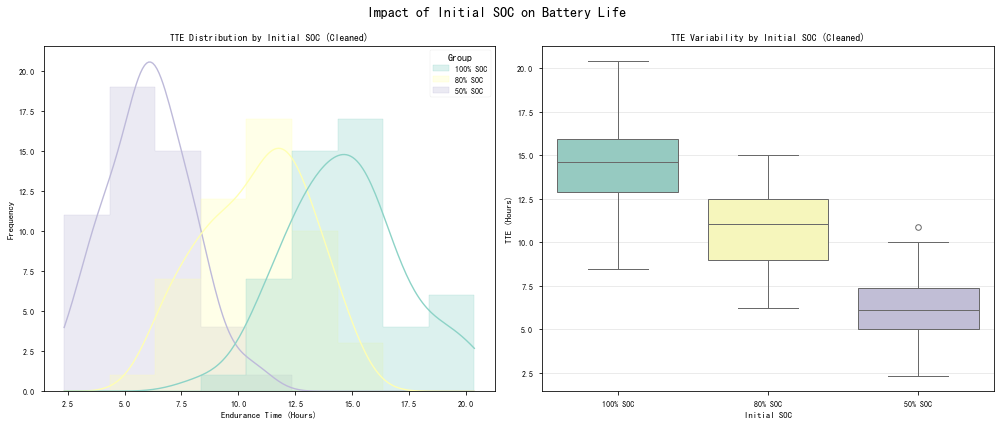

               mean       std       min        max
Group                                             
100% SOC  14.680283  2.577708  8.447500  20.383333
50% SOC    6.071022  1.844019  2.342222  10.868889
80% SOC   10.793161  2.300228  6.202500  14.983333

--- 开始实验: SOH 对比 ---
  正在模拟组别: New (100%) ...  正在模拟组别: Used (85%) ...  正在模拟组别: Aged (70%) ...

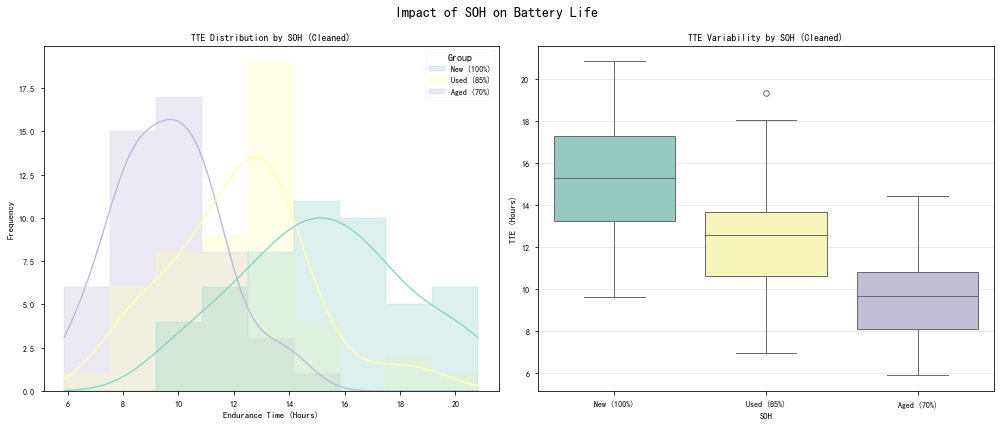

                 mean       std       min        max
Group                                               
Aged (70%)   9.647661  1.897825  5.884167  14.416667
New (100%)  15.215411  2.976637  9.600833  20.823889
Used (85%)  12.219667  2.559616  6.966667  19.321111

--- 开始实验: Temperature 对比 ---
  正在模拟组别: Cold (0°C) ...  正在模拟组别: Room (25°C) ...  正在模拟组别: Hot (45°C) ...

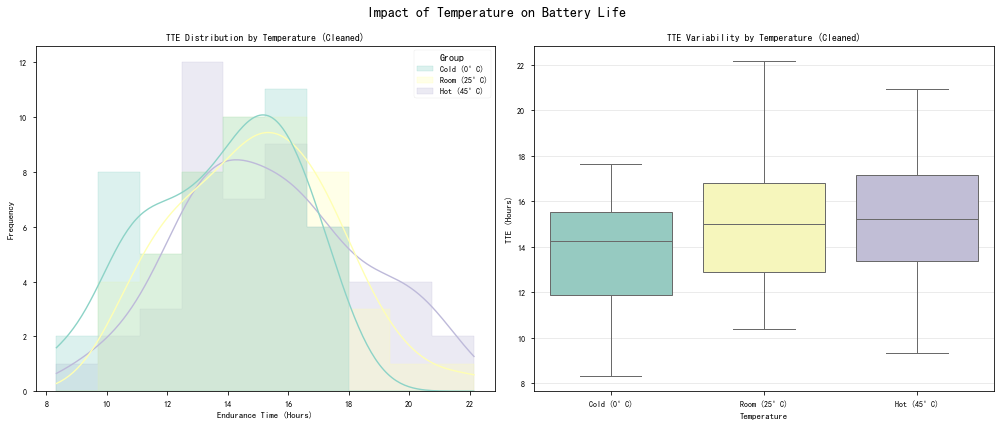

                  mean       std        min        max
Group                                                 
Cold (0°C)   13.773556  2.442068   8.333333  17.611667
Hot (45°C)   15.439094  2.938161   9.333889  20.921389
Room (25°C)  14.976433  2.595860  10.367222  22.145000

--- 开始实验: Workload 对比 ---
  正在模拟组别: Power Save (0.7x) ...  正在模拟组别: Normal (1.0x) ...  正在模拟组别: Gaming (1.5x) ...

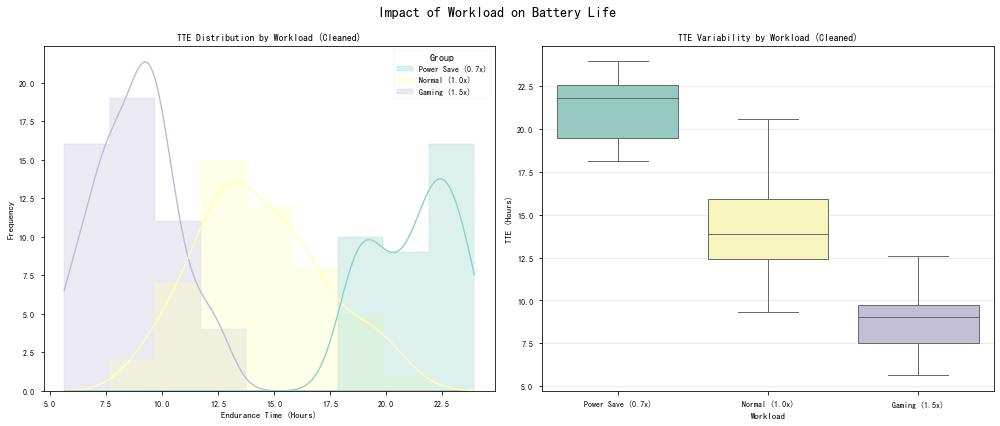

                        mean       std        min        max
Group                                                       
Gaming (1.5x)       8.839878  1.762561   5.643333  12.573056
Normal (1.0x)      14.378706  2.785387   9.346944  20.550278
Power Save (0.7x)  21.225397  1.812816  18.106389  23.934722


In [2]:
# 问题二排空时间预测对比
def run_experiment(variable_name, setting_list, n_iter=50, title_suffix=""):
 
    print(f"\n--- 开始实验: {variable_name} 对比 ---")
    results_df = pd.DataFrame()
    
    MIN_VALID_TTE = 0.1 
    
    palette = sns.color_palette("Set3", n_colors=len(setting_list))
    # 可以使用其他调色板替换“Set3”，如Set1, Set2, Set3，viridis，deep, muted, bright, pastel, dark, colorblind
    
    plt.figure(figsize=(14, 6))
    
    for i, setting in enumerate(setting_list):
        label = setting['label']
        print(f"  正在模拟组别: {label} ...", end="")
        
        valid_ttes = []
        abnormal_count = 0
        
    
    
        for _ in range(n_iter):
            cfg = BatteryConfig(soh=setting.get('soh', 1.0), env_temp=setting.get('temp', 25.0))
            sim = BatterySimulator(cfg)
            
            init_soc = setting.get('init_soc', 1.0)
            intensity = setting.get('intensity', 1.0)
            
            tte, reason = sim.run_simulation(initial_soc=init_soc, power_intensity=intensity)
            
 
            if tte > MIN_VALID_TTE:
                valid_ttes.append(tte)
            else:
                abnormal_count += 1
        
        
        
        if len(valid_ttes) > 0:
            temp_df = pd.DataFrame({'TTE (Hours)': valid_ttes, 'Group': label})
            results_df = pd.concat([results_df, temp_df])
        else:
            print(f" 组别 {label} 没有产生有效数据！")

   
    if results_df.empty:
        print("没有有效数据可供绘图。")
        return

    # --- 绘图 1: 分布直方图 (KDE) ---
    plt.subplot(1, 2, 1)
    sns.histplot(data=results_df, x='TTE (Hours)', hue='Group', kde=True, element="step", palette=palette, alpha=0.3)
    plt.title(f"TTE Distribution by {variable_name} (Cleaned)")
    plt.xlabel("Endurance Time (Hours)")
    plt.ylabel("Frequency")
    
    # --- 绘图 2: 箱线图 (Boxplot) ---
    plt.subplot(1, 2, 2)
    sns.boxplot(data=results_df, x='Group', y='TTE (Hours)', palette=palette, hue='Group', legend=False)
    plt.title(f"TTE Variability by {variable_name} (Cleaned)")
    plt.xlabel(variable_name)
    plt.grid(True, axis='y', alpha=0.3)
    
    plt.suptitle(f"Impact of {variable_name} on Battery Life {title_suffix}", fontsize=14)
    plt.tight_layout()
    plt.show()
    

    stats = results_df.groupby('Group')['TTE (Hours)'].describe()[['mean', 'std', 'min', 'max']]
    print(stats)
# ==========================================
# 执行四组对比实验
# ==========================================

# 1. 不同初始 SOC (Initial SOC)
# 控制变量: SOH=1.0, Temp=25, Intensity=1.0
settings_soc = [
    {'label': '100% SOC', 'init_soc': 1.0},
    {'label': '80% SOC',  'init_soc': 0.8},
    {'label': '50% SOC',  'init_soc': 0.5}
]
# 这里init_soc指的是不同电池初始荷电状态，可在0~1范围内调整对比
run_experiment("Initial SOC", settings_soc)

# 2. 不同 SOH (State of Health)
# 控制变量: SOC=1.0, Temp=25, Intensity=1.0
settings_soh = [
    {'label': 'New (100%)', 'soh': 1.0},
    {'label': 'Used (85%)', 'soh': 0.85},
    {'label': 'Aged (70%)', 'soh': 0.70}
]
# 这里soh指的是不同电池健康情况，可在0~1范围内调整对比
run_experiment("SOH", settings_soh)

# 3. 不同环境温度 (Temperature)
# 控制变量: SOC=1.0, SOH=1.0, Intensity=1.0
settings_temp = [
    {'label': 'Cold (0°C)',   'temp': 0.0},
    {'label': 'Room (25°C)',  'temp': 25.0},
    {'label': 'Hot (45°C)',   'temp': 45.0}
]
# 这里temp指的是不同电温度下，可在-10~45范围内调整对比
run_experiment("Temperature", settings_temp)

# 4. 不同功耗强度 (Workload Intensity)
# 控制变量: SOC=1.0, SOH=1.0, Temp=25
settings_power = [
    {'label': 'Power Save (0.7x)', 'intensity': 0.7},
    {'label': 'Normal (1.0x)',     'intensity': 1.0},
    {'label': 'Gaming (1.5x)',     'intensity': 1.5}
]
# 这里intensity指的是不同功耗下，可在0.5-2范围内调整对比
run_experiment("Workload", settings_power)